This notebook is a spin-out from the graduate course "Thermodynamics, Phase Behavior and Transport Phenomena in Materials" at UC Berkeley. 

This notebook demonstrates how to use [Julia](https://julialang.org/) to solve spinodal, binodal curves and visualize high-quality 3D surface plot that might not be straightforward using python and matplotlib.

[Julia](https://julialang.org/) realizes easy implementation of symbolic operation (e.g. differentiation) and allows us to define variables using greek letters! 🤩 

In this notebook, the following Julia packages are used:

1. [Symbolics.jl](https://symbolics.juliasymbolics.org/stable/): a fast computer algebra system (CAS) providing symbolic operation (e.g. differntiation)
2. [SciPy.jl](https://atsushisakai.github.io/SciPy.jl/stable/): a Julia interface with [SciPy](https://www.scipy.org/scipylib/index.html) using [PyCall.jl](https://github.com/JuliaPy/PyCall.jl)
3. [Latexify.jl](https://korsbo.github.io/Latexify.jl/stable/), [LaTeXStrings.jl](https://github.com/JuliaStrings/LaTeXStrings.jl), and [Plots.jl](https://docs.juliaplots.org/stable/) for math rednering and plotting


## Problem statement

Consider an incompressible system of binary particles ($A+B$) with equal volume $v_A = v_B = v$. A mean-field model for the free energy density $f$ is defined as: $$\frac{fv}{k_BT} = \phi_A \ln (\phi_A) + (1 - \phi_A) \ln (1 - \phi_A) + \chi \phi_A^2 $$, where $\phi_A$ is the volume fraction of particle $A$ and $1-\phi_A$ is the volume fraction of species $B$. 

The free energy surface is hereby defined as the function of $\phi_A$ and $\chi_A$, and the concavity of the surface defines the **stable**, **metastable** (homogeneous mixture), and **unstable** phases, separated by **binodal** and **spinodal** lines.

The spindoal line can be solved analytically by finding the inflection point of free energy surface with respect to volume fraction $\phi_A$. However, the binodal line requires solving the common tangent line of concave up regions, which in principle can only be solved numerically. 

This notebook will then demonstrate the power of Julia in lieu of the commercial software like MATLAB to tackle this problem gracefully, from symbolic differntiation to high-quality publication drawing, all based on open-source package! 

## Create a new project and install packages

Julia uses `Project.toml` and `Manifest.toml` to register the code dependency for different projects/environments. See [Pkg.jl](https://pkgdocs.julialang.org/v1/environments/) for details. The code only takes longer for the first run.

In [ ]:
using Pkg
Pkg.activate("/mnt/c/Users/qaqow/Dropbox/course")

Pkg.add("Plots")
Pkg.add("Symbolics")
Pkg.add("LaTeXStrings")
Pkg.add("Latexify")
Pkg.add("SciPy")

using Symbolics
using LaTeXStrings
using Latexify

## Define free energy function and differntial operator


In [2]:

# define varaibles and free energy function
@variables ϕ, χ;
F = ϕ*log(ϕ) + (1-ϕ)*log(1-ϕ) + χ*ϕ^2

# define differential operators
Dϕ = Differential(ϕ) # differential with respect to ϕ
Dχ = Differential(χ) # differential with resepct to χ

(::Differential) (generic function with 3 methods)

The higher-order differentials can be easily defined as the power of first differntial operator

In [3]:
DDϕ = Dϕ^2
D3ϕ = Dϕ^3

display(DDϕ(F))
display(D3ϕ(F))

Differential(ϕ)(Differential(ϕ)(χ*(ϕ^2) + ϕ*log(ϕ) + (1 - ϕ)*log(1 - ϕ)))

Differential(ϕ)(Differential(ϕ)(Differential(ϕ)(χ*(ϕ^2) + ϕ*log(ϕ) + (1 - ϕ)*log(1 - ϕ))))

To make the differentials take effect, use `expand_derivatives` and `simplify` to get the nice representation.

In [4]:
DDϕF = simplify.(expand_derivatives(DDϕ(F)))
display(DDϕF)
D3ϕF = simplify.(expand_derivatives(D3ϕ(F)))
display(D3ϕF)

(1.0 + 2.0χ*ϕ - 2.0χ*(ϕ^2)) / (ϕ*(1 - ϕ))

(2.0ϕ - 1.0) / ((ϕ^2)*((1 - ϕ)^2))

To solve the spinodal line, we can equate the second derivatives with zero and solve for $\chi$ by rearragement. 

In [5]:
χfϕ = simplify.(Symbolics.solve_for(DDϕF ~ 0, χ))

1.0 / (2.0(ϕ^2) - 2.0ϕ)

Therefore we obtain the spinodal line parameterized by $\phi$. This is done by # using `build_function` and `eval` to convert symbolic representation into a Julia's primitive function.

In [6]:
χfϕ = build_function(χfϕ, ϕ)
χfϕ = eval(χfϕ)
χfϕ

#3 (generic function with 1 method)

To solve binodal line, the gradient field of the free energy surface is needed for finding the points of tangency. 

In [7]:
DϕF = simplify.(expand_derivatives(Dϕ(F)))
χgϕ = simplify.(Symbolics.solve_for(DϕF ~ 0, χ))

display(χgϕ)

χgϕ = build_function(χgϕ, ϕ)
χgϕ = eval(χgϕ)
χgϕ

(log(ϕ) - log(1 - ϕ)) / (-2.0ϕ)

#5 (generic function with 1 method)

On the free energy surface, all the points of contengency at different χ from the binodal line and can be solved by `SciPy.optimize.fsolve` in `SciPy.jl`.

In [8]:
using SciPy

# free energy density 
f = build_function(F, ϕ, χ)
f = eval(f)

# gradient of free energy density
f_ϕ = build_function(DϕF, ϕ, χ)
f_ϕ = eval(f_ϕ)

# define objective function for SciPy.optimize.fsolve
# this function equates the tangent slope of two points
# one starts from left 0, and other one starts from right 1
function func(x, p)
    """
        x: x[1] = ϕ1, x[2] = ϕ2
        p: p = chi
    """
    fϕ1 = f(x[1], p)
    fϕ2 = f(x[2], p)

    slope = (fϕ1 - fϕ2) / (x[1] - x[2])

    return [f_ϕ(x[1], p) - slope, f_ϕ(x[2], p) - slope]
end

_χs = -5.0:0.01:-2.0

pts = []
for _χ in _χs
    root = SciPy.optimize.fsolve(func, [1e-5, 1-1e-5], args=(_χ))
    push!(pts, [root[1], _χ])
    push!(pts, [root[2], _χ])
end

pts = hcat(pts...)

# Sort based on the first column (x-values)
ind = sortperm(pts[1, :])

binodal = permutedims(pts[:, ind], (2, 1))


602×2 Matrix{Float64}:
 0.00718806  -5.0
 0.00726422  -4.99
 0.00734122  -4.98
 0.00741907  -4.97
 0.00749778  -4.96
 0.00757736  -4.95
 0.00765782  -4.94
 0.00773917  -4.93
 0.00782142  -4.92
 0.00790458  -4.91
 0.00798866  -4.9
 0.00807368  -4.89
 0.00815964  -4.88
 ⋮           
 0.991926    -4.89
 0.992011    -4.9
 0.992095    -4.91
 0.992179    -4.92
 0.992261    -4.93
 0.992342    -4.94
 0.992423    -4.95
 0.992502    -4.96
 0.992581    -4.97
 0.992659    -4.98
 0.992736    -4.99
 0.992812    -5.0

## Plot potential energy surface, spinodal, and binodal lines

[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]


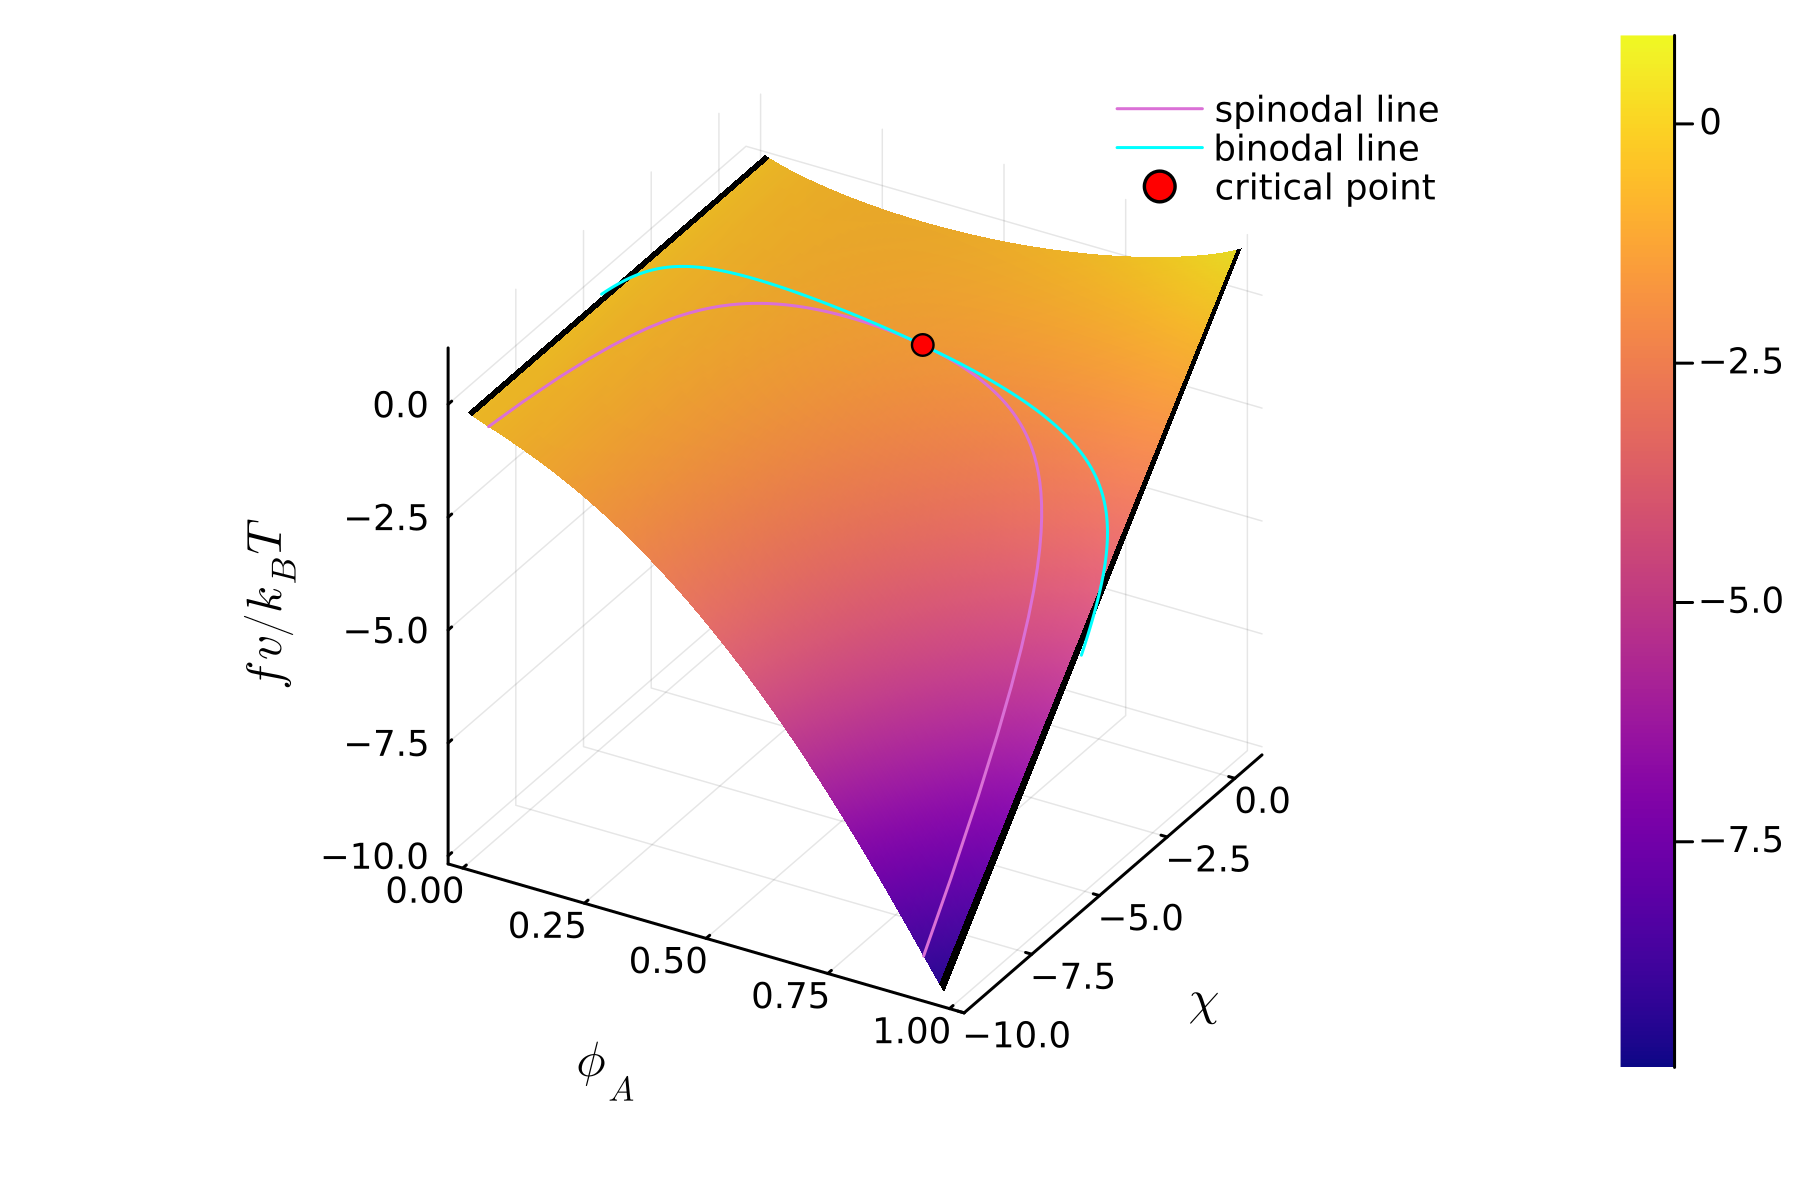

In [9]:
using Plots; gr()

# plot surface region of interest
ϕs = 0:0.01:1
χs = -10:0.01:1

p = surface(
    ϕs, χs, f,
    color=:plasma,
    # st = [:surface, :contourf],
    xlabel = L"\phi_A",
    ylabel = L"\chi",
    zlabel = L"fv/k_BT",
    # xformatter = x -> x/0.5,
    # yformatter = y -> y/-2,
    dpi=300
)

# plot spinodal line

ϕs = 0.05:0.01:0.95

plot!(
    ϕs, χfϕ, f,
    ylims = (-10,1),
    c=:orchid,
    label = "spinodal line"
)

# plot binodal line
# the suitable range of ϕ is chosen

ϕs = 0:0.01:1

plot!(
    # ϕs, χgϕ, f,
    binodal[:, 1], binodal[:, 2], f.(binodal[:, 1], binodal[:, 2]),
    ylims = (-10,1),
    c=:cyan,
    label = "binodal line"
)

# plot critical (congruent) point where spinodal and binodal lines touch

scatter!(
    [0.5], [χfϕ(0.5)], [f(0.5 ,χfϕ(0.5))],
    c=:red,
    label = "critical point"
)

plot!(
    # legend=:outerleft, legend_columns=1,
    foreground_color_legend = nothing,
    background_color_legend = nothing,
    # camera = (30, 30)
)

display(p)

If we take a slice of free energy surface, it is easier to discern the difference between spinodal and binodal lines. We can see that there is metastable gap betwen spinodal and binodal lines on the both sides. The homogenous mixture within the miscebility gap (inside spinodal line) is unstable and will undergo phase separation, with volume fraction determined by [lever rule](https://en.wikipedia.org/wiki/Lever_rule). However, if the system is located in metastable region, the system may remain homogeneous mixture since the driving force is smaller.

-3.01

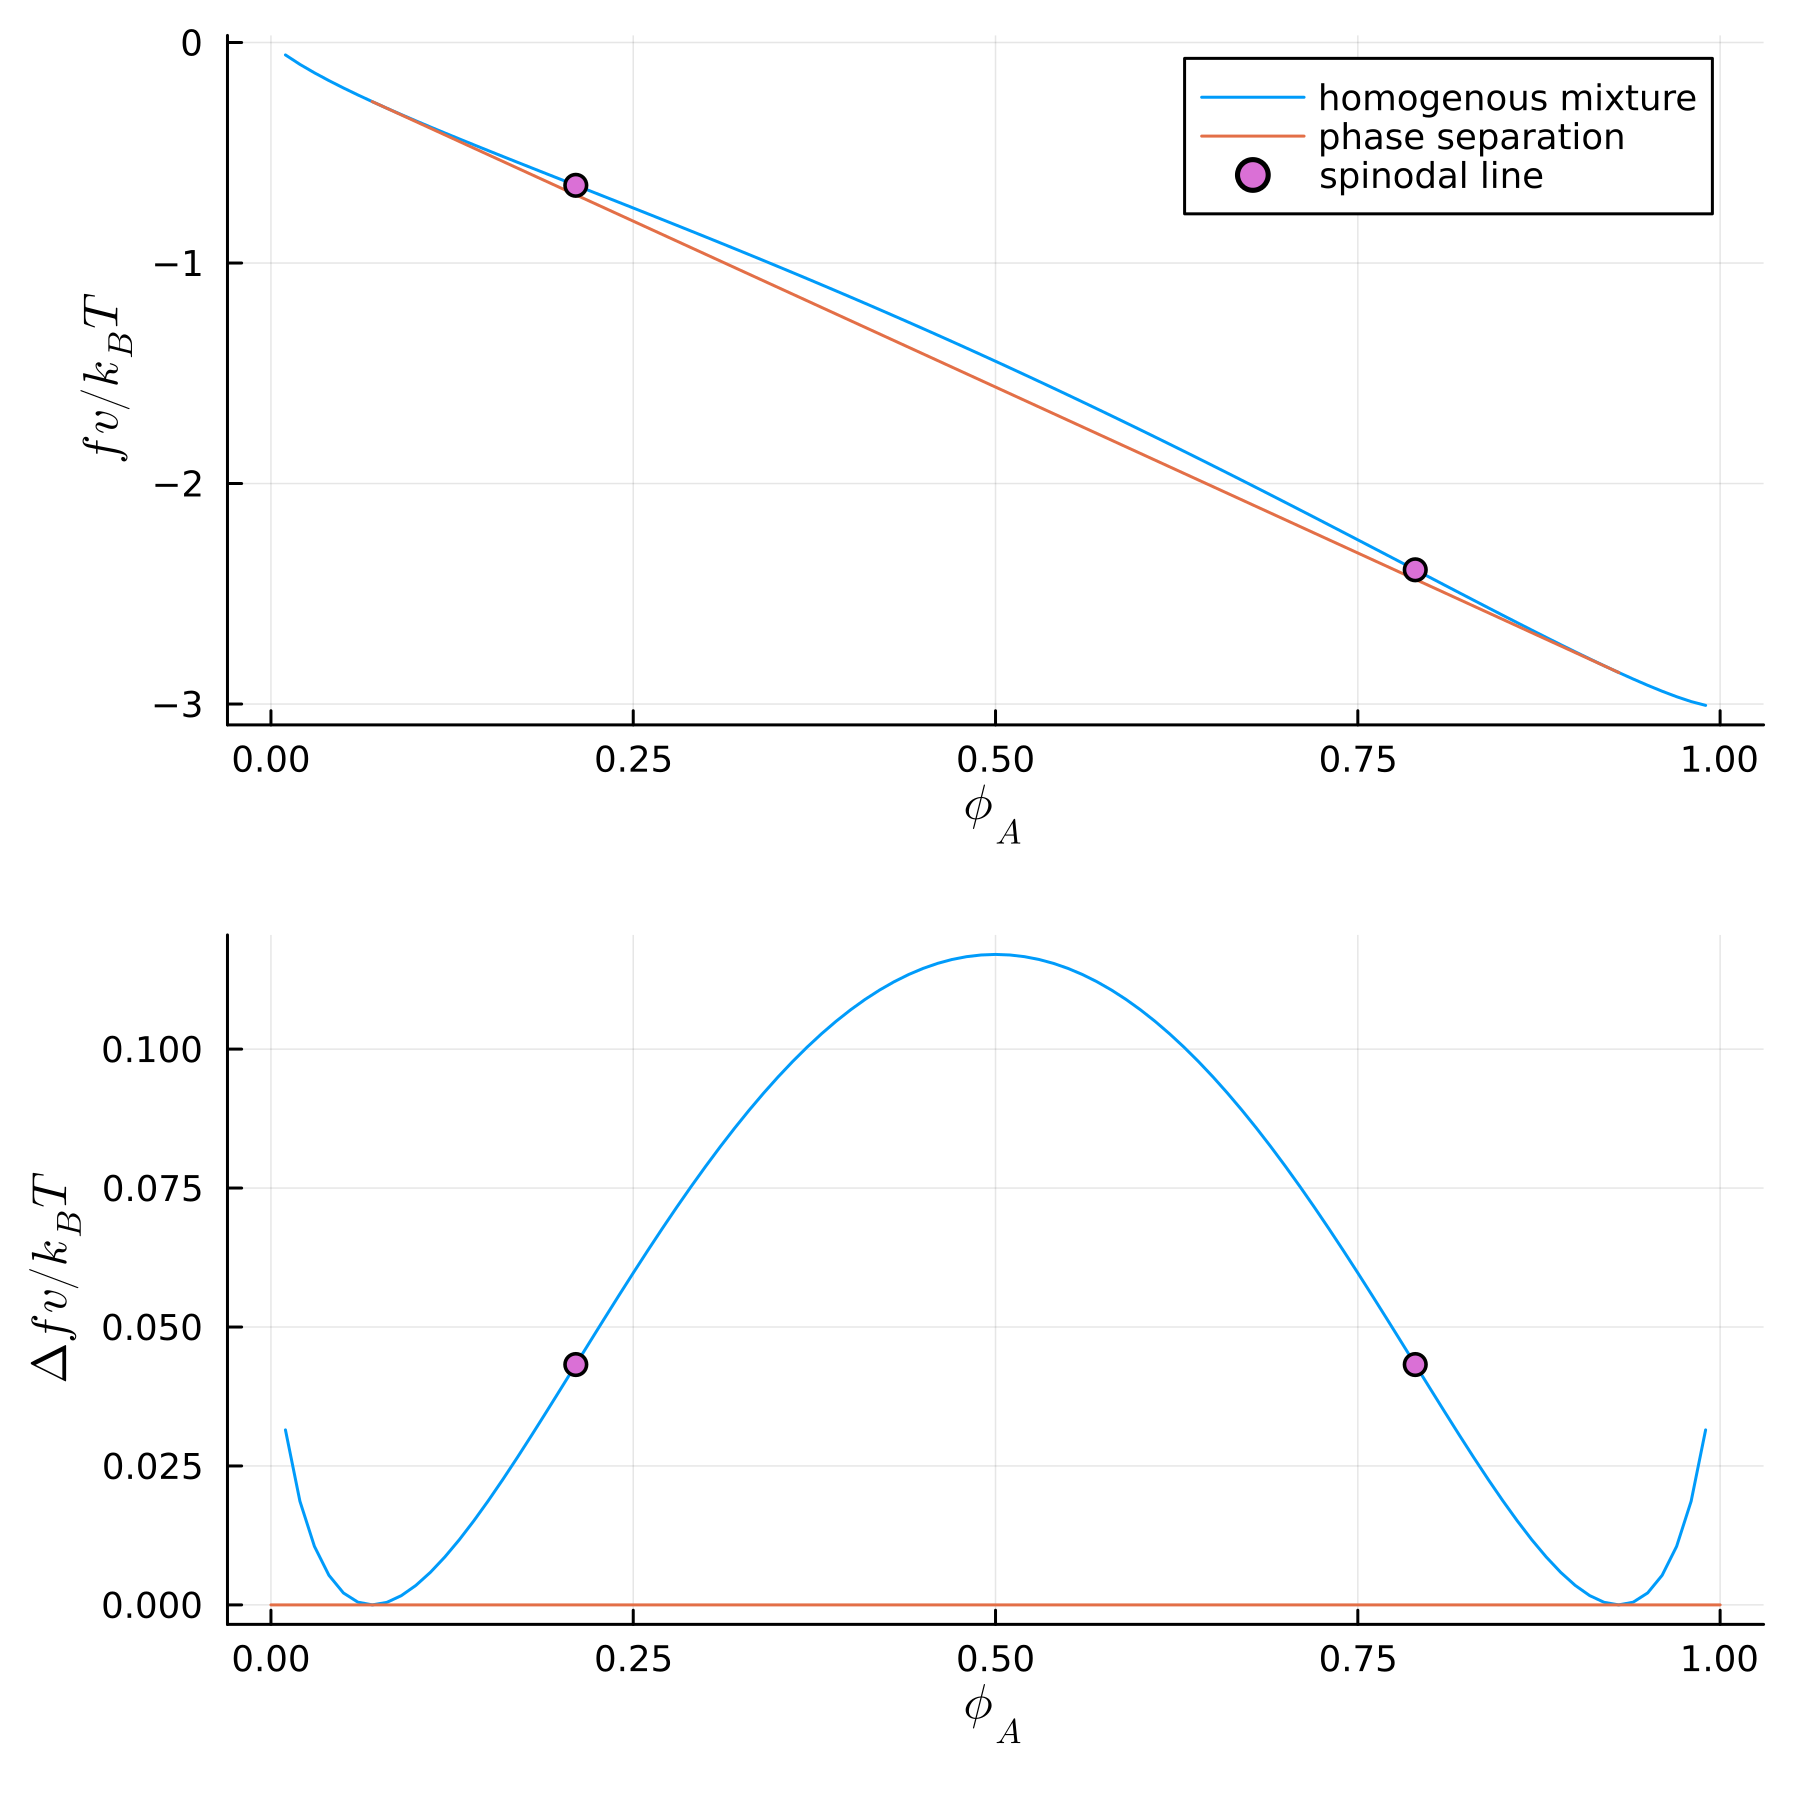

In [10]:
using Roots
using Plots; gr()

# pick one critical χ
χc = binodal[200, 2]
print(χc)

row_indices = all(binodal[:, 2] .== χc, dims=2)

p1 = plot(
    ϕs, f.(ϕs, χc),
    xlabel = L"\phi_A",
    ylabel = L"fv/k_BT",
    label = "homogenous mixture",
    dpi=300
)


plot!(
    binodal[row_indices, 1], f.(binodal[row_indices, 1], χc),
    label = "phase separation"
)

h = build_function(substitute(DDϕF, Dict([χ => χc])), ϕ)
h = eval(h)

rts = find_zeros(h, 0, 1)

scatter!(
    rts, f.(rts, χc),
    c=:orchid,
    label = "spinodal line"
)

x1, x2 = binodal[row_indices, 1]
y1, y2 = f.(binodal[row_indices, 1], χc)

m = (y2 - y1) / (x2 - x1)

t(x) = m*(x - x1) + y1

p2 = plot(
    ϕs, f.(ϕs, χc) - t.(ϕs),
    xlabel = L"\phi_A",
    ylabel = L"\Delta fv/k_BT",
    legend = false
)

plot!(
    ϕs, t.(ϕs) - t.(ϕs),
    legend = false
)

scatter!(
    rts, f.(rts, χc) - t.(rts),
    c=:orchid
)

p = plot(
    p1, p2, 
    size=(600,600),
    layout=(2,1)
)

display(p)
